# Assessment Task 2: Data exploration and preparation
## Author: Nicolas Huber
## Student ID: 25061944

# Scenario
A global space astrometry mission, Gaia is building the largest, most precise three-dimensional map of our Galaxy by surveying nearly two billion objects. Throughout the course of its mission, Gaia monitors each of its target stars about 14 times per year. It is precisely charting their positions, distances, movements, and changes in brightness. It is expected to discover hundreds of thousands of new celestial objects, such as extra-solar planets and brown dwarfs, and observe hundreds of thousands of asteroids within our own Solar System. The mission is also studying more than 1 million distant quasars and providing stringent new tests of Albert Einstein’s General Theory of Relativity.

In this task, the Head of the Analytics Unit asks you to use Gaia observation to do 2-class (A,B) stellar classification to help understand the Galaxy. As you will see, this dataset is highly complicated and includes a lot of features that make this problem more challenging.

 Your tasks include:

- understanding the specifics of the dataset;
- extracting information about each of the attributes, possible associations between them, and any other specifics of the dataset.
- The tasks in the assignment are specified below.

# 0. Preparation

In [ ]:
import os
import math
import shutil

import numpy as np
import pandas as pd

from IPython.display import display, Markdown

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.colors as mcolors
from matplotlib.colors import Normalize
import matplotlib.cm as cm

import seaborn as sns

from scipy.stats import zscore, kurtosis, skew, norm
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler, LabelBinarizer, RobustScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.ensemble import RandomForestClassifier

import umap.umap_ as umap
from sklearn.manifold import TSNE

from ydata_profiling import ProfileReport

In [ ]:
# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

In [ ]:
import matplotlib
print('matplotlib: {}'.format(matplotlib.__version__)) # downgraded due to heatmap bug

# Constants

In [ ]:
# Set a random seed
SEED = 31011997

In [ ]:
SAMPLE_RATIO = 0.1

In [ ]:
# PARAMETERS TO BE ADJUSTED
SKEWNESS_THRESHOLD = 0.5
CORRELATION_THRESHOLD = 0.7
OUTLIER_COUNT_THRESHOLD = 0
MAX_CLUSTER_LEVEL = 6

In [ ]:
# The per-pair plots write one file for every pair of numeric features (about 3,800 files, ~330 MB).
# They are off by default; set to True to regenerate them. Plots for highly correlated pairs
# (CORRELATION_THRESHOLD) are always generated.
GENERATE_PAIR_PLOTS = False

In [ ]:
sns.color_palette()

In [ ]:
sns.color_palette("viridis", as_cmap=True)

In [ ]:
sns.color_palette("coolwarm", as_cmap=True)

In [ ]:
PALETTE = 'coolwarm'
ALPHA = 0.6

In [ ]:
OUTPUT_PATH = './output'

# Data Loading

In [ ]:
os.getcwd()

In [ ]:
# Data Loading
df = pd.read_csv(filepath_or_buffer="../data/32130_AT2_25061944.csv")
header = pd.read_excel(io="../data/head_description.xlsx")

In [ ]:
#df = df.sample(frac=SAMPLE_RATIO, random_state=SEED) # To speed up

In [ ]:
df.shape

# Setup

In [ ]:
# Clearing the whole OUTPUT_PATH here also deleted files the notebook does not create
# (output/excel/task*.xlsx from the task scripts and the solution workbook).
# setup_folders() below clears only the folders the notebook writes to.


In [ ]:
# Prepare output directory
def prepare_output_dir(directory):
    # Check if directory exists
    if os.path.exists(directory):
        # Remove directory and its contents
        for root, dirs, files in os.walk(directory, topdown=False):
            for file in files:
                os.remove(os.path.join(root, file))
            for dir in dirs:
                os.rmdir(os.path.join(root, dir))
        os.rmdir(directory)

    # Create new directory
    os.makedirs(directory)

In [ ]:
def setup_folders(main_folder, subfolders):
    """
    Ensures a folder structure with multiple (potentially nested) empty subfolders.
    - main_folder: The path to the main folder.
    - subfolders: A list of subfolder paths to be created within the main folder. Nested folders can be specified using '/'.
    """

    print(f'Current working directory: {os.getcwd()}')
    # Ensure the main folder exists
    if not os.path.exists(main_folder):
        os.makedirs(main_folder)

    # Iterate through each subfolder path
    for subfolder_path in subfolders:
        full_path = os.path.join(main_folder, subfolder_path)

        # Check if the subfolder path exists
        if os.path.exists(full_path):
            # Clear the subfolder if it exists (remove then recreate)
            shutil.rmtree(full_path)

        # Create the subfolder path, including any nested directories
        os.makedirs(full_path)

In [ ]:
subfolders = ['exploration/statistics', 'exploration/features', 'exploration/reports', 'pk', 'exploration/features/jointplots', 'exploration/dimred/pca', 'exploration/dimred/hclustering']

setup_folders(OUTPUT_PATH, subfolders)

# Keep output/excel: it also holds files that the notebook does not create
os.makedirs(os.path.join(OUTPUT_PATH, 'excel'), exist_ok=True)

# 1A. Initial data exploration

Identify the attribute type of each attribute in your dataset. If it's not clear, you may need to justify why you chose the type.
For each attribute, conduct below studies for each of them: Identify the values of the summarising properties for the attributes, including frequency, location and spread (e.g. value ranges of the attributes, frequency of values, distributions, medians, means, variances, percentiles, etc. - the statistics that have been covered in the lectures and materials given). Note that not all of these summary statistics will make sense for all the attribute types, so use your judgement! Where necessary, use proper visualisations for the corresponding statistics.

Using KNIME or Python, explore multiple attributes relationship of your dataset, and identify any outliers, clusters of similar instances, "interesting" attributes and specific values of those attributes. Note that you may need to 'temporarily' recode attributes to numeric or from numeric to nominal. The report should include the corresponding snapshots from the tools and an explanation of what has been identified there.

In [ ]:
df.describe()

In [ ]:
df.dtypes

In [ ]:
# Initial Profiling report
profile_raw = ProfileReport(df, title="Profiling Report of raw Data")
profile_raw.to_file("./output/exploration/reports/profiling_report_raw.html")

In [ ]:
# Exploratory statistics

def generate_statistics(df, print_col_stats=False):

    numeric_stats = []
    non_numeric_stats = []

    for col_num, column in enumerate(df.columns):
        data = df[column]

        # Display column name
        if print_col_stats:
            display(Markdown(f'## {column}'))

        # Determine if column is numeric or categorical
        if pd.api.types.is_numeric_dtype(data):

            # Calculating Z-score outliers
            outliers_count = (np.abs(zscore(data.dropna())) > 3).sum()
            # Safely calculating Z-Score Outliers Percentage
            z_score_outliers_percentage = (outliers_count / data.count()) * 100 if outliers_count > 0 else 0



            # Descriptive Statistics for numeric data
            stats = {
                # General stats
                'Count': data.count(),
                'Mean': data.mean(),
                'Median': data.median(),
                'Mode': data.mode().values[0] if not data.mode().empty else np.nan,
                'Variance': data.var(),
                'Standard Deviation': data.std(),

                # Range
                'Range': data.max() - data.min(),
                'Minimum': data.min(),
                'Maximum': data.max(),

                # Quantiles and Outliers
                'IQR': data.quantile(0.75) - data.quantile(0.25),
                '25%': data.quantile(0.25),
                '50%': data.quantile(0.50),
                '75%': data.quantile(0.75),
                'Z-Score Outliers': outliers_count,
                'Z-Score Outliers Ratio': z_score_outliers_percentage,
                # Distribution
                'Skewness': skew(data.dropna()),
                'Kurtosis': kurtosis(data.dropna()),
                #'IQR Outliers': 'See Box Plot',


                # Values
                'Missing Values': data.isna().sum(),
                'Missing Values Ratio': data.isnull().mean() * 100,
                'Unique Values': data.nunique(),
                'Positive Values Count': (data > 0).sum(),
                'Zero Values Count': (data == 0).sum(),
                'Negative Values Count': (data < 0).sum()
            }
            numeric_stats.append(stats)


            # Plotting
            fig, ax = plt.subplots(3, 3, figsize=(18, 10))

            # First row of plots (existing plots)
            sns.boxplot(x=data, ax=ax[0, 0])
            ax[0, 0].set_title('Box Plot')

            sns.histplot(data, kde=True, ax=ax[0, 1])
            ax[0, 1].set_title('Histogram & Density Plot')

            sns.violinplot(x=data, ax=ax[0, 2])
            ax[0, 2].set_title('Violin Plot')

            # Second row for the new histogram plot
            sns.boxplot(data=df, x=data, y="SpType-ELS",
                        ax=ax[1,0],
                        palette=PALETTE,
                        )
            ax[1, 0].set_title('Boxplot by SpType-ELS')


            sns.histplot(
                df,
                x=data, hue="SpType-ELS",
                multiple="stack",
                log_scale=False,
                ax=ax[1, 1],
                palette=PALETTE,
            )
            ax[1, 1].set_title('Stacked Histogram by SpType-ELS')

            sns.violinplot(data=df, x=data, y="SpType-ELS",
                           split=True, inner="quart", fill=False,
                           ax=ax[1, 2],
                           palette='coolwarm',
                           )
            ax[1, 2].set_title('Split Violinplot by SpType-ELS')

            sns.boxenplot(
                df, x=data, y="SpType-ELS",
                ax=ax[2, 0],
                palette=PALETTE,
            )
            ax[2, 0].set_title('Boxenplot by SpType-ELS')


            ax[2, 1].axis('off')
            ax[2, 2].axis('off')


            # Overall figure title and layout adjustments
            fig.suptitle(f'Descriptive Statistics for Numerical Attribute {column}')
            plt.tight_layout()

            # Saving the figure
            plt.savefig(f'./output/exploration/statistics/stats_{col_num}_{column}_numerical.png')

            if print_col_stats:
                # Print statistics
                for key, value in stats.items():
                    display(Markdown(f'- **{key}:** {value}'))
                plt.show()
            plt.close()

        else:
            # Descriptive Statistics for categorical data
            stats = {
                'Count of Occurrences': data.value_counts(),
                'Missing Ratio': data.isnull().mean() * 100,
                'Unique Values': data.nunique()
            }
            non_numeric_stats.append(stats)

            # Visualization for categorical data
            plt.figure(figsize=(10, 5))
            sns.countplot(y=data, palette=PALETTE)
            plt.title(label=f'Frequency Count for Categorical Attribute {column}')
            plt.savefig(f'./output/exploration/statistics/stats_{col_num}_{column}_categorical.png')
            if print_col_stats:
                # Descriptive Statistics for categorical data
                display(Markdown(f'- **Count of Occurrences:**\n{data.value_counts().to_frame()}'))
                display(Markdown(f'- **Missing Ratio:** {data.isnull().mean() * 100}%'))
                display(Markdown(f'- **Unique Values:** {data.nunique()}'))

                plt.show()
            plt.close()

    # Convert stats lists to DataFrames
    # numeric_df = pd.DataFrame(numeric_stats).transpose()
    # Convert stats lists to DataFrames with column names as indices for numeric stats
    numeric_df = pd.DataFrame(numeric_stats, index=df.columns[df.apply(pd.api.types.is_numeric_dtype)]).transpose()
    non_numeric_df = pd.concat({key: pd.DataFrame(value).transpose() for key, value in enumerate(non_numeric_stats)}).unstack(0)



    # Print tables as Markdown
    print("### Numeric Columns Statistics\n")
    display(Markdown(numeric_df.transpose().to_markdown()))
    numeric_df.transpose().to_excel("./output/excel/stats_numeric.xlsx")
    print("\n### Non-Numeric Columns Statistics\n")
    display(Markdown(non_numeric_df.transpose().to_markdown()))
    non_numeric_df.to_excel("./output/excel/stats_non_numeric.xlsx")


In [ ]:
generate_statistics(df=df, print_col_stats=False)

In [ ]:
def plot_outliers_bar(df, column=None):
    # Calculate outliers for all numeric columns or a single specified column
    outlier_counts = {}
    if column:
        # Single column mode
        if pd.api.types.is_numeric_dtype(df[column]):
            data = df[column].dropna()
            outliers = np.abs(zscore(data)) > 3
            outlier_counts[column] = np.sum(outliers)
        else:
            print(f"{column} is not a numeric column.")
    else:
        # All numeric columns mode
        for col in df.columns:
            if pd.api.types.is_numeric_dtype(df[col]):
                data = df[col].dropna()
                outliers = np.abs(zscore(data)) > 3
                outlier_counts[col] = np.sum(outliers)

    # Normalize the outlier counts to use with the colormap
    norm = mcolors.Normalize(vmin=min(outlier_counts.values()), vmax=max(outlier_counts.values()))
    scalar_map = cm.ScalarMappable(norm=norm, cmap='coolwarm')

    plt.figure(figsize=(10, 5))
    for col, count in outlier_counts.items():
        color = scalar_map.to_rgba(count)
        plt.bar(col, count, color=color)
        plt.text(col, count, str(count), ha='center', color=color)

    plt.ylabel('Number of Outliers')
    plt.xticks(rotation=45, ha='right')
    plt.title('Number of Outliers in Each Numeric Column')
    plt.colorbar(scalar_map, label='Number of Outliers')
    plt.tight_layout()
    plt.savefig(f'./output/exploration/outliers_raw.png', bbox_inches='tight')
    plt.show()

In [ ]:
plot_outliers_bar(df)

In [ ]:
def gen_missing_values_barplot(df, suffix, sorted=False):
    total_number_of_rows = len(df.index)
    total_missing_values = df.isnull().sum()
    percentage_missing = (total_missing_values / total_number_of_rows) * 100

    data = pd.DataFrame({
        'Columns': df.columns,
        'Missing Values %': percentage_missing
    })

    if sorted:
        data = data.sort_values(by='Missing Values %', ascending=True)  # Sort ascending for vertical bars

    plt.figure(figsize=(max(6, 0.45 * len(df.columns)), 5))  # Adjusted figsize for vertical orientation

    # Plot for Missing Values % with vertical bars
    bars = sns.barplot(y='Missing Values %', x='Columns', data=data, color='orange')
    plt.title('Relative Percentage of Missing Values')
    plt.ylabel('Percentage')
    plt.xlabel('Columns')
    plt.xticks(rotation=45, ha="right")  # Rotate column names for better readability

    # Adjusting the position of percentage labels to avoid collision
    for bar in bars.patches:
        height = bar.get_height()
        label_x_pos = bar.get_x() + bar.get_width() / 2
        label_y_pos = height*1 if height > 0 else 1
        plt.text(label_x_pos, label_y_pos, f'{height:.1f}%',
                 ha='center', va='bottom', color='black', fontsize=9, rotation=0)

    plt.tight_layout(rect=[0, 0, 0.95, 0.95])  # Adjust layout to fit everything
    if sorted:
        plt.savefig(f'./output/exploration/missing_values_{suffix}.png', bbox_inches='tight')
    else:
        plt.savefig(f'./output/exploration/missing_values_sorted_{suffix}.png', bbox_inches='tight')
    plt.show()

In [ ]:
gen_missing_values_barplot(df=df, suffix='raw', sorted=False)

In [ ]:
gen_missing_values_barplot(df=df, suffix='raw', sorted=True)

In [ ]:
def gen_missing_values_barplot_class(df, suffix, sorted=False):
    # Assuming 'SpType-ELS' is the class column
    class_column = 'SpType-ELS'

    # Filter out rows where the class column is missing for simplicity
    df_filtered = df[df[class_column].notnull()]

    # Strip away trailing whitespaces
    df_filtered[class_column] = df_filtered[class_column].str.strip()

    # Calculate the total number of missing values for each column
    total_missing_values = df.isnull().sum()
    percentage_missing = (total_missing_values / len(df)) * 100

    # Prepare a DataFrame to hold missing value percentages by class for each column
    data_columns = df.columns.drop(class_column)  # Exclude the class column itself
    missing_values_data = pd.DataFrame(columns=data_columns, index=['Missing Values %', 'A', 'B'])

    # Calculate missing values and their class distribution using df_filtered
    for column in data_columns:
        if column != class_column:  # Ensure not to calculate for the class column itself
            column_missing_values = df_filtered[df_filtered[column].isnull()]
            total_missing = column_missing_values.shape[0]

            # Calculate proportions for classes A and B if there are missing values
            if total_missing > 0:
                missing_values_data.loc['A', column] = (column_missing_values[class_column] == 'A').sum() / total_missing * 100
                missing_values_data.loc['B', column] = (column_missing_values[class_column] == 'B').sum() / total_missing * 100
            else:
                missing_values_data.loc['A', column] = 0
                missing_values_data.loc['B', column] = 0

    missing_values_data = missing_values_data.T.fillna(0)  # Transpose and fill NA for plotting

    if sorted:
        missing_values_data = missing_values_data.sort_values('Missing Values %')

    plt.figure(figsize=(max(6, 0.45 * len(data_columns)), 3))

    # Define colors from the 'coolwarm' palette
    colors = plt.get_cmap('coolwarm')

    # Plotting with 'coolwarm' palette
    n = len(missing_values_data)
    for cls, color in zip(['A', 'B'], [colors(0.2), colors(0.8)]):  # Adjust color indices as needed
        bottom = None if cls == 'A' else missing_values_data['A']
        plt.bar(missing_values_data.index, missing_values_data[cls], bottom=bottom, label=f'Missing Values % {cls}', color=color)

    plt.title('Relative Percentage of Missing Values by Class')
    plt.xticks(rotation=45, ha="right")
    plt.xlabel('Columns')
    plt.ylabel('Percentage')
    plt.legend(loc='upper left', bbox_to_anchor=(1, 1))

    plt.tight_layout()
    plt.savefig(f'./output/exploration/missing_values_grouped_{( "sorted_" if sorted else "" )}{suffix}.png', bbox_inches='tight')
    plt.show()

In [ ]:
gen_missing_values_barplot_class(df=df, suffix='raw', sorted=False)

In [ ]:
def visualize_centralized_missing_data(df, group_column='SpType-ELS'):
    # Determine unique groups and columns
    groups = df[group_column].unique()
    columns = df.columns.difference([group_column])

    # Initialize the plot data structure
    plot_data = pd.DataFrame(index=columns, columns=groups)

    # Calculate the proportion of missing data for each column and group
    for group in groups:
        for column in columns:
            total = df[df[group_column] == group][column].shape[0]
            missing = df[df[group_column] == group][column].isnull().sum()
            plot_data.loc[column, group] = missing / total if total > 0 else 0

    # Setting up the figure
    fig, ax = plt.subplots(figsize=(5, len(columns) * 0.4))

    # Plotting each group's data
    colors = sns.color_palette("coolwarm", len(groups))
    for i, group in enumerate(groups):
        # Values are positive in both directions, mirrored around the center
        values = plot_data[group].values
        # Determine direction: left for the first group, right for the second
        direction = -1 if i == 0 else 1
        ax.barh(plot_data.index, values * direction, color=colors[i], label=group, edgecolor='black')

        # Adding value labels to bars
        for index, value in enumerate(values):
            ax.text(value * direction, index, f" {value:.2%}", va='center', ha=('right' if direction == -1 else 'left'))

    ax.set_xlabel('Proportion Missing')
    ax.set_title('Proportion of Missing Data by Column and Group')
    # Draw a central axis line
    ax.axvline(x=0, color='grey', lw=1)

    # Adjusting labels and legend
    ax.yaxis.set_tick_params(labelsize=8)
    ax.legend(title=group_column, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()

    plt.show()

In [ ]:
visualize_centralized_missing_data(df=df)

In [ ]:
def visualize_centralized_missing_data(df, group_column='SpType-ELS'):
    # Determine unique groups and columns
    groups = df[group_column].unique()
    columns = df.columns.difference([group_column])

    # Calculate the proportion of missing data for each column and group
    proportions = {group: df[df[group_column] == group].isnull().mean() for group in groups}
    proportions_df = pd.DataFrame(proportions, index=df.columns).drop(group_column, errors='ignore')

    # Set up the plot
    fig, ax = plt.subplots(figsize=(10, len(columns) * 0.1))

    # Plot settings
    width = 0.35  # the width of the bars
    ind = np.arange(len(columns))  # the x locations for the groups

    for i, group in enumerate(groups):
        # Plotting
        values = proportions_df[group]
        pos = ind - width/2 + i*width
        ax.bar(pos, values, width, label=group, color=sns.color_palette("coolwarm", len(groups))[i])

    ax.set_title('Proportion of Missing Data by Group and Column')
    ax.set_xticks(ind)
    ax.set_xticklabels(columns, rotation=45, ha="right")
    ax.set_yticks(np.linspace(0, 1, 11))
    ax.set_ylabel('Proportion Missing')
    ax.axhline(0, color='grey', linewidth=0.8)
    ax.legend(title=group_column, bbox_to_anchor=(1.05, 1), loc='upper left')


    plt.tight_layout()
    plt.show()

In [ ]:
visualize_centralized_missing_data(df=df)

# Initial Data Exploration Insights

Following our preliminary examination of the dataset, we identified the following patterns regarding missing data:

- A substantial portion of data, **97.0%**, is absent from the `pscol` column, indicating a critical lack of information within this field.
- The `GRVSmag` column is missing **41.6%** of its data, highlighting a significant gap in our dataset.
- Similarly, **41.6%** of the data in the `e_GRVSmag` column is missing, paralleling the situation in the `GRVSmag` column.
- The `Age-Flame` column has **25.2%** missing data, suggesting a moderate amount of information is unavailable.
- A smaller, yet noteworthy, **8.1%** of data is missing from the `Mass-Flame` column.
- Only a minimal **2.4%** of data is missing in both the `z-Flame` and `Lum-Flame` columns, indicating these fields are largely complete.
- All other columns are fully populated with data, showing no gaps in information.

These observations provide a critical foundation for subsequent data cleaning and imputation strategies to ensure comprehensive data analysis.

# Enhanced Approaches for Handling Missing Data

In addressing the challenge of missing data, we will undertake specific actions tailored to the unique characteristics of each column as outlined below:

| Column       | % Missing | Missing Count | Recommended Action       | Rationale                                                                                                                                                                                                                                                                    |
|--------------|-----------|---------------|--------------------------|------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| `pscol`      | 97.0%     | Very High     | Drop column              | The column is missing nearly all its data, rendering it impractical for any meaningful analysis or recovery.                                                                                                                                                                 |
| `GRVSmag`    | 41.6%     | High          | Impute with Median       | Given the boxplot's significant value drop between 12 to 13, despite a steady increase from 6 to 11, imputing with the median is advised to maintain robustness. Additional domain knowledge is needed to assess normal distribution characteristics for precise imputation. |
| `e_GRVSmag`  | 41.6%     | High          | Impute with Mean         | The error distribution primarily clusters around 0, then declines sharply with a long, flat tail, suggesting an exponential distribution. Averaging is preferred for imputation in this context.                                                                             |
| `Age-Flame`  | 25.2%     | Moderate      | Impute with Median       | With a notable drop in values between 0.3 to 0.7 and a continuous rise thereafter, median imputation is recommended to "fill the gap" and aim for a normal-like distribution, pending further domain insight.                                                                |
| `Mass-Flame` | 8.1%      | Low           | Delete missing data rows | The relatively minor proportion of missing data allows for direct removal without significant impact on the dataset's integrity.                                                                                                                                             |
| `z-Flame`    | 2.4%      | Minimal       | Delete missing data rows | Given the negligible amount of missing data, row deletion is a straightforward and minimally disruptive solution.                                                                                                                                                            |
| `Lum-Flame`  | 2.4%      | Minimal       | Delete missing data rows | Similar to `z-Flame`, the sparse missing data warrants simple row removal for data cleanliness without losing substantial information.                                                                                                                                       |

The above actions are proposed to strategically address missing data issues across various columns, ensuring that data integrity and analytical validity are maintained throughout the dataset processing phase.

In [ ]:
plt.figure(figsize=(32, 32))
sns.pairplot(df, hue='SpType-ELS', palette=PALETTE)
plt.savefig('./output/exploration/features/pairplot_raw.png')

In [ ]:
# Define the columns you want to plot
columns_to_plot = ['RA_ICRS', 'GRVSmag', 'e_GRVSmag', 'Teff', 'Age-Flame', 'SpType-ELS']

# Select only the specified columns from your dataframe
df_subset = df[columns_to_plot]

# Create the pairplot
plt.figure(figsize=(16, 16))
sns.pairplot(df_subset, hue='SpType-ELS', palette=PALETTE)
plt.savefig('./output/exploration/features/pairplot_selected_columns_raw.png')

## Correlations

In [ ]:
#pd.plotting.scatter_matrix(df, alpha=ALPHA)
#plt.savefig('./output/exploration/correlation-map.png')

In [ ]:
# Select only numeric columns
df_only_numeric_columns = df.select_dtypes(include=['float64', 'int64'])
# Compute correlation matrix
corr_matrix = df_only_numeric_columns.corr()

# Create a mask for the upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Visualize correlation matrix
plt.figure(figsize=(16, 16))
ax = sns.heatmap(data=corr_matrix, annot=True, cmap=PALETTE, mask=mask, fmt=".2f", linewidths=0.5)
plt.savefig('./output/exploration/features/correlation_heatmap_raw.png')

In [ ]:
# Stack the correlation matrix to get pairs of features and their correlations
correlation_pairs = corr_matrix.stack().reset_index()
correlation_pairs.columns = ['Feature 1', 'Feature 2', 'Correlation']

# Sort by correlation values in descending order
sorted_correlation_pairs = correlation_pairs.sort_values(by='Correlation', ascending=False)

print(sorted_correlation_pairs)

In [ ]:
# Filter correlation pairs above the threshold, excluding those involving the same column and duplicates
high_correlation_pairs = sorted_correlation_pairs[
    (sorted_correlation_pairs['Correlation'] > CORRELATION_THRESHOLD) &
    (sorted_correlation_pairs['Feature 1'] < sorted_correlation_pairs['Feature 2'])  # Exclude duplicates
    ]

# Plotting the bar chart
plt.figure(figsize=(10, 6))
bars = plt.barh(high_correlation_pairs['Feature 1'] + ' - ' + high_correlation_pairs['Feature 2'],
                high_correlation_pairs['Correlation'], color='skyblue')
plt.xlabel('Correlation')
plt.ylabel('Feature Pair')
plt.title(f'Correlated Feature Pairs with Correlation > {CORRELATION_THRESHOLD} (excluding same feature and duplicates)')
plt.gca().invert_yaxis()  # Invert y-axis for better readability

# Annotate bars with correlation values
for bar, correlation in zip(bars, high_correlation_pairs['Correlation']):
    plt.text(bar.get_width(), bar.get_y() + bar.get_height() / 2, f'{correlation:.2f}',
             va='center', ha='left')

plt.tight_layout()
plt.show()
plt.savefig('./output/exploration/features/correlated_features_hierarchy_raw.png')

In [ ]:
# This functions creates single files
def scatter_plot_between_attributes_based_on_corr_subplots(df_including_class_col, ignore_same_col_corr=True, corr_threshold=0.7, above_correlation=False):
    df = df_including_class_col.select_dtypes(include=['float64', 'int64'])

    unique_classes = df_including_class_col['SpType-ELS'].unique()
    colors = plt.cm.coolwarm(np.linspace(0, 1, len(unique_classes)))
    markers = ['o', 'x', 's', 'D', '^', 'v', '<', '>', 'p', '*', '+']

    class_colors = {class_name: color for class_name, color in zip(unique_classes, colors)}
    class_markers = {class_name: marker for class_name, marker in zip(unique_classes, markers[:len(unique_classes)])}

    for n_index, column in enumerate(df.columns):
        for m_index, column_iterator in enumerate(df.columns):
            if ignore_same_col_corr and column == column_iterator:
                continue

            correlation = df.iloc[:, n_index].corr(df.iloc[:, m_index])
            abs_corr = abs(correlation)
            corr_condition = abs_corr >= corr_threshold if above_correlation else abs_corr <= corr_threshold

            if corr_condition:
                x = df.iloc[:, n_index]
                y = df.iloc[:, m_index]
                class_labels = df_including_class_col['SpType-ELS']

                try:
                    slope, intercept = np.polyfit(x, y, 1)
                    line = slope * x + intercept
                    plot_regression_line = True
                except np.linalg.LinAlgError:
                    plot_regression_line = False

                plt.figure(figsize=(6, 6))

                for class_value in unique_classes:
                    idx = df_including_class_col['SpType-ELS'] == class_value
                    plt.scatter(x[idx], y[idx], c=[class_colors[class_value]], marker=class_markers[class_value], label=class_value, alpha=ALPHA)

                if plot_regression_line:
                    plt.plot(x, line, color='black', linestyle='-.')

                plt.xlabel(column)
                plt.ylabel(column_iterator)
                plt.title(f'Feature {column} vs. Feature {column_iterator} - (Correlation: {correlation:.2f})')
                plt.legend()

                filename = f'{column}-{column_iterator}-scatter.png'.replace('/', '-')
                corr_dir = 'corr_above' if above_correlation else 'corr_below'
                dir_path = f'./output/exploration/features/{corr_dir}_scatterplot_{corr_threshold}'

                os.makedirs(dir_path, exist_ok=True)
                plt.savefig(f'{dir_path}/{filename}')
                #print(n_index, column, m_index, column_iterator)
                plt.tight_layout()
                #plt.show()
                plt.close()

In [ ]:
def scatter_plot_between_attributes_based_on_corr(df_including_class_col, ignore_same_col_corr=True, corr_threshold=0.7, above_correlation=False):
    df = df_including_class_col.select_dtypes(include=['float64', 'int64'])

    # Preparing class colors and markers
    unique_classes = df_including_class_col['SpType-ELS'].unique()
    colors = plt.cm.coolwarm(np.linspace(0, 1, len(unique_classes)))
    markers = ['o', 'x', 's', 'D', '^', 'v', '<', '>', 'p', '*', '+']
    class_colors = {class_name: color for class_name, color in zip(unique_classes, colors)}
    class_markers = {class_name: marker for class_name, marker in zip(unique_classes, markers[:len(unique_classes)])}

    # Calculate the total number of plots more explicitly
    total_plots = 0
    for n_index, column in enumerate(df.columns):
        for m_index, column_iterator in enumerate(df.columns):
            if ignore_same_col_corr and column == column_iterator:
                continue

            correlation = df.iloc[:, n_index].corr(df.iloc[:, m_index])
            abs_corr = abs(correlation)
            corr_condition = (abs_corr >= corr_threshold) if above_correlation else (abs_corr <= corr_threshold)

            if corr_condition:
                total_plots += 1

    # Determine grid size for subplots
    grid_size = math.ceil(math.sqrt(total_plots))

    # Create a single figure for all subplots
    fig, axs = plt.subplots(grid_size, grid_size, figsize=(5*grid_size, 5*grid_size))
    fig.subplots_adjust(hspace=0.4, wspace=0.4)  # Adjust spacing between plots

    # Flatten the axes array for easy indexing
    axs = axs.flatten()
    plot_count = 0

    for n_index, column in enumerate(df.columns):
        for m_index, column_iterator in enumerate(df.columns):
            if ignore_same_col_corr and column == column_iterator:
                continue

            correlation = df.iloc[:, n_index].corr(df.iloc[:, m_index])
            abs_corr = abs(correlation)
            corr_condition = (abs_corr >= corr_threshold) if above_correlation else (abs_corr <= corr_threshold)

            if corr_condition:
                x = df.iloc[:, n_index]
                y = df.iloc[:, m_index]

                # Attempt to fit a linear regression line
                try:
                    slope, intercept = np.polyfit(x, y, 1)
                    line = slope * x + intercept
                    plot_regression_line = True
                except np.linalg.LinAlgError:
                    plot_regression_line = False

                # Plot in the next subplot position
                ax = axs[plot_count]
                for class_value in unique_classes:
                    idx = df_including_class_col['SpType-ELS'] == class_value
                    ax.scatter(x[idx], y[idx], c=[class_colors[class_value]], marker=class_markers[class_value], label=class_value, alpha=ALPHA)

                if plot_regression_line:
                    ax.plot(x, line, color='black', linestyle='-.')

                ax.set_xlabel(column)
                ax.set_ylabel(column_iterator)
                ax.set_title(f'{column} vs. {column_iterator} - (Correlation: {correlation:.2f})')
                #if plot_count == 0:  # Add legend only to the first plot to save space
                    #ax.legend()
                ax.legend()

                print(n_index, column, m_index, column_iterator)
                plot_count += 1


    # Hide any unused subplots
    for idx in range(plot_count, len(axs)):
        axs[idx].axis('off')

    # Save the entire figure with all subplots
    filename = f'./output/exploration/correlation-scatter.png'
    plt.savefig(filename)
    if above_correlation:
        plt.title(f'Correlated Feature Pairs with an absolute Correlation value of > {corr_threshold}')
    else:
        plt.title(f'Correlated Feature Pairs with an absolute Correlation value of < {corr_threshold}')
    plt.show()

In [ ]:
scatter_plot_between_attributes_based_on_corr_subplots(df_including_class_col=df, ignore_same_col_corr=True, corr_threshold=CORRELATION_THRESHOLD, above_correlation=True)

In [ ]:
# Plots every feature pair (threshold 0); only runs when GENERATE_PAIR_PLOTS is True
if GENERATE_PAIR_PLOTS:
    scatter_plot_between_attributes_based_on_corr_subplots(df_including_class_col=df, ignore_same_col_corr=True, corr_threshold=0, above_correlation=True) # Plot all

In [ ]:
scatter_plot_between_attributes_based_on_corr(df_including_class_col=df, ignore_same_col_corr=True, corr_threshold=CORRELATION_THRESHOLD, above_correlation=True)

In [ ]:
def distribution_plot_between_attributes_based_on_corr_subplots(df_including_class_col, ignore_same_col_corr=True, corr_threshold=0.7, above_correlation=False):
    df = df_including_class_col.select_dtypes(include=['float64', 'int64'])

    # Loop through each pair of columns to check for correlation
    for n_index, column in enumerate(df.columns):
        for m_index, column_iterator in enumerate(df.columns):
            if ignore_same_col_corr and column == column_iterator:
                continue

            correlation = df[column].corr(df[column_iterator])
            abs_corr = abs(correlation)
            corr_condition = abs_corr >= corr_threshold if above_correlation else abs_corr <= corr_threshold

            if corr_condition:
                # Prepare data with correct column names for plotting
                data = pd.concat([df[column], df[column_iterator], df_including_class_col['SpType-ELS']], axis=1)
                data.columns = [column, column_iterator, 'Class']

                # Create a figure to contain the custom layout
                plt.figure(figsize=(10, 15))

                # First subplot: regression plot
                plt.subplot(3, 1, 1)
                sns.regplot(data=data, x=column, y=column_iterator)
                plt.xlabel(column)  # Set x-axis label
                plt.ylabel(column_iterator)  # Set y-axis label
                plt.title('Regression Plot')

                # Second subplot: scatter plot with hue
                plt.subplot(3, 1, 2)
                sns.scatterplot(data=data, x=column, y=column_iterator, hue='Class', palette=PALETTE, alpha=ALPHA)
                plt.xlabel(column)  # Set x-axis label
                plt.ylabel(column_iterator)  # Set y-axis label
                plt.title('Scatter Plot with Hue for different classes A and B')

                # Third subplot: KDE plot
                plt.subplot(3, 1, 3)
                sns.kdeplot(data=data, x=column, y=column_iterator, fill=True)
                plt.xlabel(column)  # Set x-axis label
                plt.ylabel(column_iterator)  # Set y-axis label
                plt.title('KDE Plot')

                # Finalize and save the figure
                plt.suptitle(f'Distribution Plots for {column} vs. {column_iterator} (Correlation: {correlation:.2f})')
                plt.tight_layout()
                plt.subplots_adjust(top=0.85)  # Adjust top space to fit suptitle

                # Save figure
                corr_dir = 'corr_above' if above_correlation else 'corr_below'
                dir_path = f'./output/exploration/features/{corr_dir}_jointplot_{corr_threshold}'
                os.makedirs(dir_path, exist_ok=True)
                filename = f'{column}-{column_iterator}-joint.png'.replace('/', '-')
                plt.savefig(f'{dir_path}/{filename}')
                plt.close()

In [ ]:
# Plots every feature pair (threshold 0); only runs when GENERATE_PAIR_PLOTS is True
if GENERATE_PAIR_PLOTS:
    distribution_plot_between_attributes_based_on_corr_subplots(df_including_class_col=df, ignore_same_col_corr=True, corr_threshold=0, above_correlation=True)

In [ ]:
def jointplots_between_attributes_based_on_corr_subplots(df_including_class_col, ignore_same_col_corr=True, corr_threshold=0.7, above_correlation=False):
    df = df_including_class_col.select_dtypes(include=['float64', 'int64'])

    # Loop through each pair of columns
    for n_index, column in enumerate(df.columns):
        for m_index, column_iterator in enumerate(df.columns):
            if ignore_same_col_corr and column == column_iterator:
                continue

            correlation = df[column].corr(df[column_iterator])
            abs_corr = abs(correlation)
            corr_condition = abs_corr >= corr_threshold if above_correlation else abs_corr <= corr_threshold

            if corr_condition:
                # Data for jointplot
                data = pd.concat([df[column], df[column_iterator], df_including_class_col['SpType-ELS']], axis=1)
                data.columns = [column, column_iterator, 'SpType-ELS']

                # Directory setup
                corr_dir = 'corr_above' if above_correlation else 'corr_below'
                dir_path = f'./output/exploration/features/jointplots/{corr_dir}_jointplot_{corr_threshold}'
                os.makedirs(dir_path, exist_ok=True)

                # Regression plot
                g_reg = sns.jointplot(data=data, x=column, y=column_iterator, kind='reg')
                g_reg.fig.suptitle(f'Regression: {column} vs. {column_iterator}')
                reg_filename = f'{column}-{column_iterator}-regression.png'.replace('/', '-')
                g_reg.savefig(f'{dir_path}/{reg_filename}')
                plt.close(g_reg.fig)

                # Scatter plot with hue
                g_scatter = sns.jointplot(data=data, x=column, y=column_iterator, hue='SpType-ELS', palette=PALETTE, alpha=ALPHA)
                g_scatter.fig.suptitle(f'Scatter with Hue: {column} vs. {column_iterator}')
                scatter_filename = f'{column}-{column_iterator}-scatter.png'.replace('/', '-')
                g_scatter.savefig(f'{dir_path}/{scatter_filename}')
                plt.close(g_scatter.fig)

                # KDE plot
                g_kde = sns.jointplot(data=data, x=column, y=column_iterator, kind='kde')
                g_kde.fig.suptitle(f'KDE: {column} vs. {column_iterator}')
                kde_filename = f'{column}-{column_iterator}-kde.png'.replace('/', '-')
                g_kde.savefig(f'{dir_path}/{kde_filename}')
                plt.close(g_kde.fig)

In [ ]:
# Plots every feature pair (threshold 0); only runs when GENERATE_PAIR_PLOTS is True
if GENERATE_PAIR_PLOTS:
    jointplots_between_attributes_based_on_corr_subplots(df_including_class_col=df, ignore_same_col_corr=True, corr_threshold=0, above_correlation=True)

In [ ]:
df.to_pickle("./output/pk/raw_data.pkl")

# Handle missing data / values

In [ ]:
# DEVELOPMENT ONLY
df = pd.read_csv(filepath_or_buffer="../data/32130_AT2_25061944.csv")
#df = df.sample(frac=SAMPLE_RATIO, random_state=SEED)

In [ ]:
df_orig = df.copy(deep=True) # deep copy
# orig will be converted to Excel file at the end, works as protocol
# original dataframe  will be prepared to actual doing data analysis

In [ ]:
# Drop pscol since most of the data is missing
# This will be done later
# df.drop(['pscol'], axis=1, inplace=True)

In [ ]:
def impute_values(column, df, df_orig, method='median'):
    # Fill missing values in column with values
    mask = df[column].isnull()
    if method == 'median':
        fill_value = df[column].median()
        
        
        df[column] = df[column].fillna(fill_value)

        filled_values = df[column].fillna(df[column].median())
        df_orig.loc[mask, f'{column}_imputed_median'] = filled_values[mask] # copies only imputed values
        return df, df_orig
    elif method == 'mean':
        fill_value = df[column].mean()
        
        df[column] = df[column].fillna(fill_value)

        filled_values = df[column].fillna(df[column].mean())
        df_orig.loc[mask, f'{column}_imputed_median'] = filled_values[mask] # copies only imputed values
        return df, df_orig
    else:
        raise ValueError("Invalid method. Please choose 'median' or 'mean'.")

In [ ]:
def impute_values(column, df, df_orig, method='median', class_based=False, class_column='SpType-ELS'):
    # Fill missing values in column with values
    mask = df[column].isnull()
    
    if class_based:
        unique_classes = df[class_column].unique()
        for cls in unique_classes:
            class_mask = df[class_column] == cls
            if method == 'median':
                fill_value = df.loc[class_mask, column].median()
            elif method == 'mean':
                fill_value = df.loc[class_mask, column].mean()
            else:
                raise ValueError("Invalid method. Please choose 'median' or 'mean'.")
            
            # Impute for specific class
            df.loc[class_mask & mask, column] = fill_value
            df_orig.loc[class_mask & mask, f'{column}_imputed_{method}'] = fill_value
            
    else:
        if method == 'median':
            fill_value = df[column].median()
        elif method == 'mean':
            fill_value = df[column].mean()
        else:
            raise ValueError("Invalid method. Please choose 'median' or 'mean'.")
        
        # General imputation
        df[column] = df[column].fillna(fill_value)
        df_orig.loc[mask, f'{column}_imputed_{method}'] = fill_value

    return df, df_orig

In [ ]:
df, df_orig = impute_values('GRVSmag', df, df_orig, 'median', True)

In [ ]:
df, df_orig = impute_values('e_GRVSmag', df, df_orig, 'median', True)

In [ ]:
df, df_orig = impute_values('Age-Flame', df, df_orig, 'median', True)

In [ ]:
def delete_rows(column, df, df_orig):
    # Delete rows containing nan-value in column
    print(f'Number of rows before dropping: {df.shape[0]}')
    deleted_rows_mask = df[column].isnull()  # Mask to identify rows to be deleted
    deleted_rows_index = df[deleted_rows_mask].index  # Index of rows to be deleted

    df = df.dropna(subset=[column])  # Dropping rows with NaN in column
    print(f'Number of rows after dropping: {df.shape[0]}')

    # Mark the corresponding rows in df_orig where values were deleted
    df_orig[f'{column}_deleted_rows'] = ''  # New column and initialize with empty string
    df_orig.loc[deleted_rows_index, f'{column}_deleted_rows'] = f'DELETED ROW due to missing {column} value'
    return df, df_orig

In [ ]:
df, df_orig = delete_rows('Mass-Flame', df, df_orig)

In [ ]:
df, df_orig = delete_rows('z-Flame', df, df_orig)

In [ ]:
df, df_orig = delete_rows('Lum-Flame', df, df_orig)

In [ ]:
df.to_pickle("./output/pk/cleaned_missing_data.pkl")
df_orig.to_pickle("./output/pk/cleaned_missing_data_protocol.pkl")
df_orig.to_excel("./output/excel/cleaned_missing_data_protocol.xlsx")

# 1B. Data preprocessing

Perform each of the following data preparation tasks (each task applies to the original data) using your choice of tool:

## Task 1
Use the following binning techniques to smooth the values of the following two attributes:
- RA_ICRS
- DE_ICRS
For each attribute, you must apply:

Equi-width binning
Equi-depth binning
In the assignment report, for each of these techniques, you need to illustrate your steps. In your Excel workbook file place the results in separate columns in the corresponding spreadsheet. Use your judgement in choosing the appropriate number of bins - and justify this in the report.

In [77]:
# Equi-width binning
def equi_width_binning(series, n_bins):
    min_value, max_value = series.min(), series.max()
    bin_edges = np.linspace(min_value, max_value, n_bins + 1)

    # Use pd.cut to handle the binning based on calculated edges
    bins = pd.cut(series, bins=bin_edges, labels=False, include_lowest=True)

    return bins

In [78]:
# Equi-depth binning
def equi_depth_binning(series, n_bins):
    sorted_series = series.sort_values()
    values_per_bin = len(series) // n_bins

    bins = pd.Series(index=series.index, dtype=int)
    for i, (index, value) in enumerate(sorted_series.items()):
        bins.at[index] = i // values_per_bin

    bins = bins.clip(upper=n_bins-1)

    return bins

In [79]:
# Define number of bins based on common best-practices; might be adjusted later
n_bins =  round(math.sqrt(df.shape[0]))

In [80]:
# Equi-width binning on RA_ICRS
df[f'RA_ICRS_equip_width_{n_bins}'] = equi_width_binning(df['RA_ICRS'], n_bins=n_bins)
df_orig[f'RA_ICRS_added_equip_width_{n_bins}'] = equi_width_binning(df['RA_ICRS'], n_bins=n_bins)

In [81]:
# Equi-depth binning on RA_ICRS
df[f'RA_ICRS_equip_depth_{n_bins}'] = equi_depth_binning(df['RA_ICRS'], n_bins=n_bins)
df_orig[f'RA_ICRS_added_depth_width_{n_bins}'] = equi_depth_binning(df['RA_ICRS'], n_bins=n_bins)

In [82]:
# Equi-width binning on DE_ICRS
df[f'DE_ICRS_equip_width_{n_bins}'] = equi_width_binning(df['DE_ICRS'], n_bins=n_bins)
df_orig[f'DE_ICRS_added_equip_width_{n_bins}'] = equi_width_binning(df['DE_ICRS'], n_bins=n_bins)

In [83]:
# Equi-depth binning on DE_ICRS
df[f'DE_ICRS_equip_depth_{n_bins}'] = equi_depth_binning(df['DE_ICRS'], n_bins=n_bins)
df_orig[f'DE_ICRS_added_depth_width_{n_bins}'] = equi_depth_binning(df['DE_ICRS'], n_bins=n_bins)

In [104]:
def plot_binning_results_with_group_proportions(df, col_equip_width, col_equip_depth, group_col):
    groups = list(df[group_col].unique())  # Ensure 'groups' is explicitly a list
    colors = sns.color_palette(PALETTE, len(groups))

    # Extracting 'n_bins' and column base name (e.g., 'DE_ICRS') from the column names
    n_bins = int(col_equip_width.split('_')[-1])  # Assuming the naming convention ends with '_n_bins'
    col_base_name = '_'.join(col_equip_width.split('_')[:-3])  # Assuming the structure 'PREFIX_equip_width_n_bins'
    
    fig, axs = plt.subplots(2, 1, figsize=(10, 4), sharex=True)

    binning_methods = [(col_equip_width, "Equi-Width"), (col_equip_depth, "Equi-Depth")]
    for ax, (col, method) in zip(axs, binning_methods):
        counts = df.groupby([col, group_col]).size().unstack(fill_value=0)
        total_counts = counts.sum(axis=1)
        proportions = counts.div(total_counts, axis=0)

        bottoms = pd.Series([0] * len(proportions), index=proportions.index)
        bars = []  # Reset bars for each plot to collect new set of bars for the legend
        for group, color in zip(groups, colors):
            bar = ax.bar(proportions.index, proportions[group], bottom=bottoms, color=color, label=group)
            bars.append(bar)
            bottoms += proportions[group]

        ax.set_title(f"{col_base_name} ({method}, Bins = {n_bins})")
        ax.set_ylabel('Proportion')

    axs[1].legend(handles=[b[0] for b in bars[-len(groups):]], labels=groups, loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=len(groups), title=group_col)
    axs[1].set_xlabel('Bin Number')
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # Adjust the layout
    plt.show()
    fig.savefig(f'./output/exploration/binning_{col_base_name}.png')

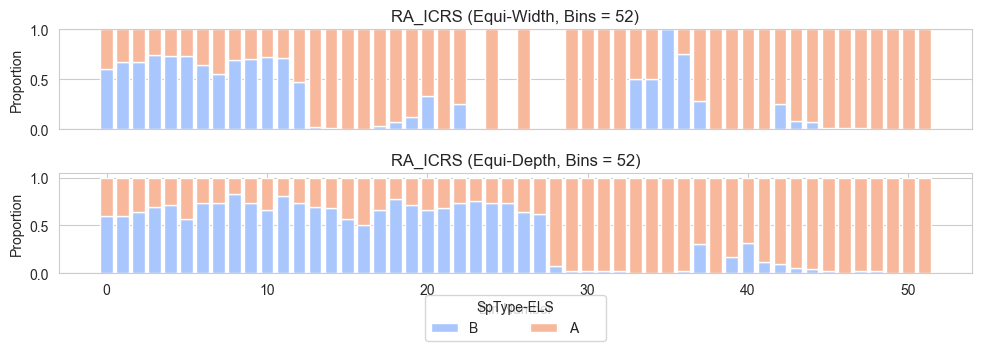

In [105]:
plot_binning_results_with_group_proportions(df, f'RA_ICRS_equip_width_{n_bins}', f'RA_ICRS_equip_depth_{n_bins}', 'SpType-ELS')


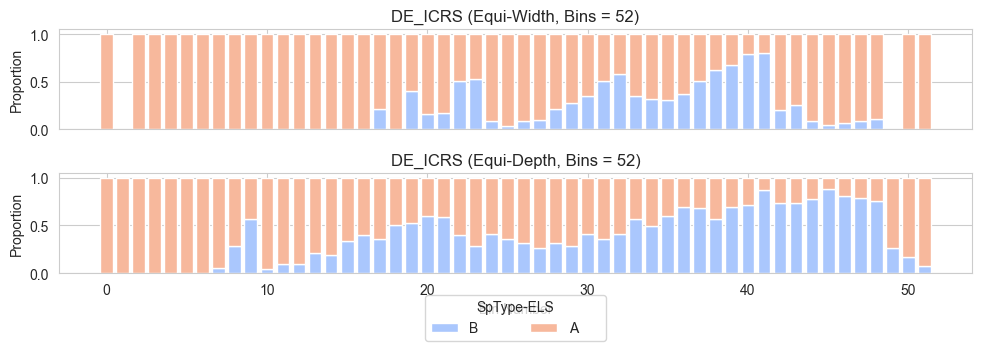

In [106]:
plot_binning_results_with_group_proportions(df, 'DE_ICRS_equip_width_{}'.format(n_bins), 'DE_ICRS_equip_depth_{}'.format(n_bins), 'SpType-ELS')

## Task 2
Use the following techniques to normalise the following attribute:
- Age-Flame
For this attribute, you must apply:

min-max normalization to transform the values onto the range [0.0-1.0].
z-score normalization to transform the values.
The assignment report provides an explanation of each of the applied techniques. In your Excel workbook file place the results in separate columns in the corresponding spreadsheet.

In [ ]:
def scale_column(column, df, df_orig, method='minmax'):
    """
    Scales a column in 'df' using the specified 'method' and appends the scaled values to 'df_orig'.

    Parameters:
    - column: the column name in 'df' to be scaled.
    - df: the original DataFrame containing the column to be scaled.
    - df_orig: the DataFrame to which the scaled values will be appended.
    - method: the scaling method to use ('minmax', 'robust', 'softmax', or 'standard').

    Returns:
    - df: the DataFrame with the scaled column added.
    - df_orig: the DataFrame with the scaled column values appended.
    """

    # Select the scaler based on the 'method' parameter
    if method == 'minmax':
        scaler = MinMaxScaler()
    elif method == 'robust':
        scaler = RobustScaler()
    elif method == 'standard':
        scaler = StandardScaler()
    else:
        raise ValueError(f"Unsupported scaling method ({method}). Choose 'minmax', 'robust', or 'standard'.")

    # Reshape the data to (-1, 1) because it's a single feature
    values = df[column].values.reshape(-1, 1)

    # Apply the selected scaler
    if method == 'softmax':
        # Custom softmax scaling
        exp_values = np.exp(values - np.max(values))
        scaled_values = exp_values / np.sum(exp_values)
    else:
        # Scikit-learn scaling
        scaled_values = scaler.fit_transform(values)

    # Assign scaled values back to df with a new column name
    df[f'{column}_scaled_{method}'] = scaled_values.flatten()

    # Create a temporary Series for the scaled values with the same index as df
    scaled_series = pd.Series(scaled_values.flatten(), index=df.index)

    # Mask to identify rows with non-null values that were scaled
    mask = ~df[column].isnull()

    # Assign scaled values to df_orig based on the mask
    df_orig.loc[df.index[mask], f'{column}_applied_scaled_{method}'] = scaled_series[mask].values

    return df, df_orig

In [ ]:
df, df_orig = scale_column('Age-Flame', df, df_orig, 'minmax')

In [ ]:
df, df_orig = scale_column('Age-Flame', df, df_orig, 'standard')

## Task 3
Discretise the Mass-Flame attribute into the following categories: Small (0 - 2) Medium (2 — 4) Large (4 — 8) Provide the frequency of each category in your dataset.
Your assignment report should provide an explanation of each of the applied techniques. In your Excel workbook file place the results in a separate column in the corresponding spreadsheet.

In [ ]:
def discretize_column(column, df, df_orig, bins, categories):
    """
    Discretizes the specified column into categories based on bins, encodes the categories numerically,
    and appends the numerically encoded values to another DataFrame.

    Parameters:
    - column: the column name in 'df' to be discretized and encoded.
    - df: the DataFrame containing the column to be processed.
    - df_orig: the DataFrame to which the numerically encoded values will be appended.
    - bins: the bins used for discretization.
    - categories: the labels for the discretized categories.

    Returns:
    - df: the DataFrame with the added categorized and numerically encoded columns.
    - df_orig: the DataFrame with the numerically encoded column values appended.
    """

    # Discretize the column based on the provided bins and categories
    categorized_column_name = f'{column}_categorized'
    df[categorized_column_name] = pd.cut(df[column], bins=bins, labels=categories, right=False)

    # Initialize the LabelEncoder
    label_encoder = LabelEncoder()

    # Fit and transform the categories to numeric values
    numeric_column_name = f'{column}_numeric'
    df[numeric_column_name] = label_encoder.fit_transform(df[categorized_column_name])

    # Mask to identify rows with non-null values in the categorized column
    mask = ~df[categorized_column_name].isnull()

    # Append the numerically encoded values to df_orig based on the mask
    df_orig.loc[df.index[mask], f'{column}_applied_category'] = df.loc[mask, categorized_column_name].values
    df_orig.loc[df.index[mask], f'{column}_applied_numeric'] = df.loc[mask, numeric_column_name].values

    return df, df_orig

In [ ]:
# Introduce categories and the corresponding quantities
mass_flame_categories = ['Small', 'Medium', 'Large']
mass_flame_bins = [0, 2, 4, 8]

df, df_orig = discretize_column('Mass-Flame', df, df_orig, mass_flame_bins, mass_flame_categories)

In [ ]:
# Display the frequency of the categories
frequencies = df['Mass-Flame_categorized'].value_counts()
frequencies

## Task 4
Binarise the SpType-ELS variable [with values "0" or "1"].
Your assignment report should provide an explanation of the applied binarisation technique. In your Excel workbook file place the results in separate columns in the corresponding spreadsheet.

In [ ]:
# Trim trailing spaces in 'SpType-ELS' column
df['SpType-ELS'] = df['SpType-ELS'].str.strip()

In [ ]:
spytype_els_classes = df['SpType-ELS'].unique()
spytype_els_classes[1]

In [ ]:
def binarize_column(column, df, df_orig, positive_class):
    """
    Binarizes a specified column based on a positive class or classes and appends
    the binarized values to another DataFrame. It treats occurrences of the positive
    class(es) as 1 and all others as 0.

    Parameters:
    - column: the column name in 'df' to be binarized.
    - df: the DataFrame containing the column to be processed.
    - df_orig: the DataFrame to which the binarized values will be appended.
    - positive_class: a list of unique values to be treated as the positive class (1).

    Returns:
    - df: the DataFrame with the added binarized column.
    - df_orig: the DataFrame with the binarized column values appended.
    """

    # Directly create a binarized column based on whether the value is in positive_classes
    df[f'{column}_binarized'] = df[column].apply(lambda x: 1 if x in positive_classes else 0)

    # Mask to identify rows with non-null values in the original column
    mask = ~df[column].isnull()

    # Append the binarized values to df_orig based on the mask
    df_orig.loc[df.index[mask], f'{column}_applied_binarized'] = df.loc[mask, f'{column}_binarized'].values

    return df, df_orig

In [ ]:
positive_classes = spytype_els_classes[0] # define A as positive class
df, df_orig = binarize_column('SpType-ELS', df, df_orig, positive_classes)

# Further Preprocessing

## Index

In [ ]:
# THIS DOES MESS UP THE PROTOCOL DF, if we need to do it, do it at the very end!
# Sort by Source
# df = df.sort_values(by=['Source'])

In [ ]:
# Apply insert new index column
# df.insert(len(df.columns), 'Source cleaned', range(0, 0 + len(df)))
# df = df.reset_index(drop=True)
# df

## Unnamed column wrangling

In [ ]:
# Check Unnamed: 0.1 and Unnamed: 0
# Action 1: compare and reduce to one column since we have duplicate entries with some prefixes in Unnamed: 0.1 col

def normalize_value(value1, value2):
    # Convert values to strings to handle them uniformly
    str_value1, str_value2 = str(value1), str(value2)

    # Remove leading numbers if they make the rest of the string identical
    for i in range(0, min(len(str_value1), len(str_value2))):
        if str_value1.endswith(str_value2[i:]):
            return int(str_value2[i:])
        if str_value2.endswith(str_value1[i:]):
            return int(str_value1[i:])

    # Default case: if both values are identical or no prefix logic is found
    return int(str_value1) if len(str_value1) < len(str_value2) else int(str_value2)

In [ ]:
# Apply the normalization to each row and create a new column with cleaned values
df['Unnamed: 0 cleaned'] = df.apply(lambda row: normalize_value(row['Unnamed: 0.1'], row['Unnamed: 0']), axis=1)
df

# Drop columns

In [ ]:
df.columns

In [ ]:
drop_reasons = [
    {'pscol': 'More than 97% of this column is missing.'},
    {'Unnamed: 0.1' : 'No information about the content of this column; probably the result of a loading and saving the data in pandas.'},
    {'Unnamed: 0' : 'No information about the content of this column; probably the result of a loading and saving the data in pandas.'},
    {'Unnamed: 0 cleaned' : 'No information about the content of this column; probably the result of a loading and saving the data in pandas.'},
    {'Source' : 'Similar to an ID, which does not provide additional information to the actual data.'},
    {'Source cleaned': 'Similar to an ID, which does not provide additional information to the actual data.'},
    {'RA_ICRS' : 'Original row, that was preprocessed using binning.'},
    {f'RA_ICRS_equip_depth_{n_bins}': 'Row that was preprocessed using binning, does not add more information to the data.'},
    {'DE_ICRS' : 'Original row, that was preprocessed using binning.'},
    {f'DE_ICRS_equip_depth_{n_bins}': 'Row that was preprocessed using binning, does not add more information to the data.'},
    {'Age-Flame' : 'Original row, that was preprocessed using minmax standardization.'} ,
    {'Age-Flame_scaled_minmax' : 'Row that was preprocessed using minmax standardization, does not add more information to the data.'},
    {'Mass-Flame' : 'Original row, that was preprocessed using discretization.'} ,
    {'Mass-Flame_categorized': 'Row that was preprocessed using discretization, does not add more information to the data.'},
    {'SpType-ELS': 'Original row, that was preprocessed using binarization.'},
]

In [ ]:
for drop_reason in drop_reasons:
    for col, reason in drop_reason.items():
        if col in df.columns:
            print(f"{col} is dropped because: {reason}")
            df_orig[f"{col}_deleted_col"] = df[col]
            df.drop([col], axis=1, inplace=True)
            df_orig[f"{col}_deleted_col"] = f"DELETED ROW due to: {reason}"
        else:
            print(f"{col} is not present in df.")

In [ ]:
df.columns

In [ ]:
gen_missing_values_barplot(df=df, suffix='cleaned', sorted=False)

In [ ]:
gen_missing_values_barplot(df=df, suffix='cleaned', sorted=True)

In [ ]:
# Profiling report after preprocessing
profile_cleaned = ProfileReport(df, title="Profiling Report of clean Data")
profile_cleaned.to_file("./output/exploration/reports/profiling_report_cleaned.html")

In [ ]:
df.to_pickle("./output/pk/cleaned_data.pkl")
df_orig.to_pickle("./output/pk/cleaned_data_protocol.pkl")
df_orig.to_excel("./output/excel/cleaned_data_protocol.xlsx")

## Standardizing


- MinMaxScaler if your data has a clear minimum and maximum and you want to scale the features to a specific range.
- StandardScaler if your data is normally distributed and you want to scale the features to have a mean of 0 and a standard deviation of 1.
- RobustScaler if your data contains outliers and you want to scale the features while preserving the relative differences between data points.

In [ ]:
df.columns

In [ ]:
already_processed = ['RA_ICRS_equip_width_16', 'DE_ICRS_equip_width_16', 'Age-Flame_scaled_minmax', 'Age-Flame_scaled_standard', 'Mass-Flame_numeric', 'SpType-ELS_binarized'] # TODO: Refactor

In [ ]:
def suggest_scaler_for_df(df, already_processed=[]):
    columns_dict = {}
    for column in df.columns:
        if column not in already_processed:
            if pd.api.types.is_numeric_dtype(df[column]):
                data_skewness = skew(df[column].dropna())
                Q1, Q3 = df[column].quantile([0.25, 0.75])
                IQR = Q3 - Q1
                outlier_count = ((df[column] < (Q1 - 1.5 * IQR)) | (df[column] > (Q3 + 1.5 * IQR))).sum()

                # Initialize dictionary for the column
                columns_dict[column] = {'scaler': None, 'reason': ''}

                # Suggesting scaler based on skewness and outliers
                if abs(data_skewness) > SKEWNESS_THRESHOLD:
                    if outlier_count > OUTLIER_COUNT_THRESHOLD:
                        columns_dict[column]['scaler'] = 'robust'
                        columns_dict[column]['reason'] = 'High skewness and outliers present'
                    else:
                        columns_dict[column]['scaler'] = 'minmax'
                        columns_dict[column]['reason'] = 'High skewness'
                else:
                    if outlier_count > OUTLIER_COUNT_THRESHOLD:
                        columns_dict[column]['scaler'] = 'robust'
                        columns_dict[column]['reason'] = 'Outliers present'
                    else:
                        columns_dict[column]['scaler'] = 'standard'
                        columns_dict[column]['reason'] = 'Data is fairly normal'
            else:
                # Non-numeric column
                columns_dict[column] = {'scaler': None, 'reason': 'Not numeric'}
    return columns_dict

In [ ]:
normalization_reasons = suggest_scaler_for_df(df, already_processed)

In [ ]:
def pretty_print_normalization_dict(normalization_dict):
    for key, value in normalization_dict.items():
        print(f'{key}:')
        print(f"    Scaler: {value['scaler']}")
        print(f"    Reason: {value['reason']}\n")

In [ ]:
pretty_print_normalization_dict(normalization_reasons)

In [ ]:
for column, info in normalization_reasons.items():
    if info['scaler']:
        print(f"Scaling {column} using {info['scaler']}")
        df, df_orig = scale_column(column, df, df_orig, method=info['scaler'])

        # we drop it afterward and append the reason to the dict
        print(f"{column} is dropped because: Original row, that was preprocessed using {info['scaler']} standardization.")
        df_orig[f"{col}_deleted_col"] = df[column]
        df.drop([column], axis=1, inplace=True)
        df_orig[f"{col}_deleted_col"] = f"DELETED ROW due to: {info['scaler']} standardization"

In [ ]:
df.to_pickle("./output/pk/preprocessed_data.pkl")
df_orig.to_pickle("./output/pk/preprocessed_data_protocol.pkl")
df_orig.to_excel("./output/excel/preprocessed_data_protocol.xlsx")

# Correlation

In [65]:
df = pd.read_pickle('./output/pk/preprocessed_data.pkl')
df_orig = pd.read_pickle("./output/pk/preprocessed_data_protocol.pkl")

In [ ]:
#TODO: Refactor, since we already have this code

In [ ]:
# Select only numeric columns
df_only_numeric_columns = df.select_dtypes(include=['float64', 'int64'])
# Compute correlation matrix
corr_matrix = df_only_numeric_columns.corr()

# Create a mask for the upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Visualize correlation matrix
plt.figure(figsize=(16, 16))
ax = sns.heatmap(data=corr_matrix, annot=True, cmap=PALETTE, mask=mask, fmt=".2f", linewidths=0.5)
plt.savefig('./output/exploration/features/correlation_heatmap_preprocessed.png')

In [ ]:
# Stack the correlation matrix to get pairs of features and their correlations
correlation_pairs = corr_matrix.stack().reset_index()
correlation_pairs.columns = ['Feature 1', 'Feature 2', 'Correlation']

In [ ]:
# Sort by correlation values in descending order
sorted_correlation_pairs = correlation_pairs.sort_values(by='Correlation', ascending=False)

print(sorted_correlation_pairs)

In [ ]:
# Filter correlation pairs above the threshold, excluding those involving the same column and duplicates
high_correlation_pairs = sorted_correlation_pairs[
    (sorted_correlation_pairs['Correlation'] > CORRELATION_THRESHOLD) &
    (sorted_correlation_pairs['Feature 1'] < sorted_correlation_pairs['Feature 2'])  # Exclude duplicates
]

# Adjusting figure size and layout for clarity and visibility of names
plt.figure(figsize=(10, 0.5 * len(high_correlation_pairs)))  # Adjust height dynamically based on number of pairs
bars = plt.barh(high_correlation_pairs['Feature 1'] + ' - ' + high_correlation_pairs['Feature 2'],
                high_correlation_pairs['Correlation'], color='skyblue')
plt.xlabel('Correlation')
plt.ylabel('Feature Pair')
plt.title(f'Correlated Feature Pairs with Correlation > {CORRELATION_THRESHOLD} (excluding same feature and duplicates)')
plt.gca().invert_yaxis()  # Invert y-axis for better readability

# Annotate bars with correlation values
for bar, correlation in zip(bars, high_correlation_pairs['Correlation']):
    plt.text(bar.get_width(), bar.get_y() + bar.get_height() / 2, f'{correlation:.2f}',
             va='center', ha='left')

plt.tight_layout()  # Adjust layout to make room for label

# Before saving, adjust the layout to prevent cutting off label texts
plt.savefig('./output/exploration/features/correlated_features_hierarchy_preprocessed.png', bbox_inches='tight')

plt.show()

In [ ]:
high_correlation_pairs

In [ ]:
corr_matrix = df.corr().abs()

# Select upper triangle of correlation matrix
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Find features with correlation greater than 0.8
high_correlation_columns = [column for column in upper_tri.columns if any(upper_tri[column] > CORRELATION_THRESHOLD)]
high_correlation_columns

In [ ]:
feature_to_be_dropped = [ # 'Gmag_scaled_robust',
                         'BPmag_scaled_robust',
                         'e_BPmag_scaled_robust',
                         'RPmag_scaled_robust',
                         'e_RPmag_scaled_robust',
                         'BP-RP_scaled_robust',
                         'BP-G_scaled_robust',
                         'G-RP_scaled_robust',
                         # 'Teff_scaled_robust',
                         'Dist_scaled_robust'
                        ]

In [66]:
df.columns

Index(['Age-Flame_scaled_standard', 'Mass-Flame_numeric',
       'SpType-ELS_binarized', 'Plx_scaled_robust', 'PM_scaled_robust',
       'pmRA_scaled_robust', 'pmDE_scaled_robust', 'Gmag_scaled_robust',
       'e_Gmag_scaled_robust', 'BPmag_scaled_robust', 'e_BPmag_scaled_robust',
       'RPmag_scaled_robust', 'e_RPmag_scaled_robust', 'GRVSmag_scaled_robust',
       'e_GRVSmag_scaled_robust', 'BP-RP_scaled_robust', 'BP-G_scaled_robust',
       'G-RP_scaled_robust', 'Teff_scaled_robust', 'Dist_scaled_robust',
       'Rad_scaled_robust', 'Lum-Flame_scaled_robust', 'z-Flame_scaled_robust',
       'RA_ICRS_equip_width_52_scaled_minmax',
       'DE_ICRS_equip_width_52_scaled_robust'],
      dtype='object')

In [67]:
for col in feature_to_be_dropped:
    print(f"{col} is dropped to minimize overall correlation.")
    # Log the column data before dropping
    df_orig[f"{col}_deleted_col"] = df[col]
    # Drop the column from the original DataFrame
    df.drop(col, axis=1, inplace=True)
    # Mark the column as deleted in the log DataFrame
    df_orig[f"{col}_deleted_col_reason"] = "DELETED due to: minimize overall correlation"

BPmag_scaled_robust is dropped to minimize overall correlation.
e_BPmag_scaled_robust is dropped to minimize overall correlation.
RPmag_scaled_robust is dropped to minimize overall correlation.
e_RPmag_scaled_robust is dropped to minimize overall correlation.
BP-RP_scaled_robust is dropped to minimize overall correlation.
BP-G_scaled_robust is dropped to minimize overall correlation.
G-RP_scaled_robust is dropped to minimize overall correlation.
Dist_scaled_robust is dropped to minimize overall correlation.


In [ ]:
# Select only numeric columns
df_only_numeric_columns = df.select_dtypes(include=['float64', 'int64'])
# Compute correlation matrix
corr_matrix = df_only_numeric_columns.corr()

# Create a mask for the upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Visualize correlation matrix
plt.figure(figsize=(16, 16))
ax = sns.heatmap(data=corr_matrix, annot=True, cmap=PALETTE, mask=mask, fmt=".2f", linewidths=0.5)
plt.savefig('./output/exploration/correlation_heatmap_final.png')

# Dimred

## PCA

In [ ]:
pca = PCA()
pca.fit(df)
var_ratio = pca.explained_variance_ratio_

In [ ]:
fig = plt.figure(figsize=(10,8))
plt.plot(range(1, len(var_ratio)+1), var_ratio.cumsum(), marker='o', linestyle='--')
plt.title('Explained Variance by Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
fig.savefig('./output/exploration/dimred/pca_variance_by_principal_components.png')

In [ ]:
PCA_COMPONENTS = 2

In [ ]:
pca = PCA(n_components=PCA_COMPONENTS)
pca.fit(df)
scores_pca = pca.transform(df)
print(scores_pca)

# Clustering

In [ ]:
wcss = []
for i in range(1, 21):
    kmeans_pca = KMeans(n_clusters=i, init='k-means++', random_state=SEED)
    kmeans_pca.fit(scores_pca)
    wcss.append(kmeans_pca.inertia_)

In [ ]:
fig = plt.figure(figsize = (10,8))
plt.plot(range(1, 21), wcss, marker='o', linestyle='--')
plt.title('K-means witch PCA Clustering')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
fig.savefig('./output/exploration/dimred/pca_no_clusters.png')

In [ ]:
OPTIMAL_N_CLUSTER = 2

In [ ]:
kmeans_pca = KMeans(n_clusters=OPTIMAL_N_CLUSTER, init='k-means++', random_state=SEED)
kmeans_pca.fit(scores_pca)

In [ ]:
df_segm_pca_kmeans = pd.concat([df.reset_index(drop=True), pd.DataFrame(scores_pca)], axis=1)
df_segm_pca_kmeans.columns.values[-PCA_COMPONENTS:] = ['PComp 1', 'PComp 2']

df_segm_pca_kmeans['Segment K-means PCA'] = kmeans_pca.labels_

In [ ]:
fig = plt.figure(figsize = (10,8))
plt.plot(range(1, 21), wcss, marker='o', linestyle='--')
plt.title('K-means witch PCA Clustering')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
fig.savefig('./output/exploration/dimred/pca_no_clusters_wcss.png')

In [ ]:
df_segm_pca_kmeans['Segment'] = df_segm_pca_kmeans['Segment K-means PCA'].map({0: 'A',
                                                                               1: 'B',
                                                                               })

In [ ]:
x_axis = df_segm_pca_kmeans['PComp 1']
y_axis = df_segm_pca_kmeans['PComp 2']
plt.figure(figsize=(10,8))
sns.scatterplot(x=x_axis, y=y_axis, hue = df_segm_pca_kmeans['Segment'], palette=PALETTE)
plt.show()

In [ ]:
df_cluster = df_segm_pca_kmeans.iloc[:,-OPTIMAL_N_CLUSTER+2:] # N components + hue + cat
df_cluster.head

In [ ]:
for n_index, column in enumerate(df_cluster.columns[:PCA_COMPONENTS]):
    for m_index, column_iterator in enumerate(df_cluster.columns[:PCA_COMPONENTS]):
        #print(n_index, column, m_index, column_iterator)
        fig = plt.figure(figsize=(5, 5))
        sns.scatterplot(x=df_cluster[column], y=df_cluster[column_iterator], hue = df_segm_pca_kmeans['Segment'], palette=PALETTE)
        plt.xlabel(column)
        plt.ylabel(column_iterator)
        plt.title('Clusters by PCA Component')
        fig.savefig('./output/exploration/dimred/pca/PCA {} vs {}.png'.format(column, column_iterator))
        #plt.show()

In [ ]:
# PCA
pca = PCA(n_components=PCA_COMPONENTS)
pca_transformed = pca.fit_transform(df)

In [ ]:
# UMAP
umap_reducer = umap.UMAP(n_components=PCA_COMPONENTS, random_state=SEED)
umap_transformed = umap_reducer.fit_transform(df)

In [ ]:
# t-SNE
tsne = TSNE(n_components=PCA_COMPONENTS, random_state=SEED)
tsne_transformed = tsne.fit_transform(df)

In [ ]:
# Cluster labels with KMeans for each DR technique
kmeans_pca = KMeans(n_clusters=OPTIMAL_N_CLUSTER, random_state=SEED).fit(pca_transformed)
labels_pca = kmeans_pca.labels_

In [ ]:
kmeans_umap = KMeans(n_clusters=OPTIMAL_N_CLUSTER, random_state=SEED).fit(umap_transformed)
labels_umap = kmeans_umap.labels_

In [ ]:
kmeans_tsne = KMeans(n_clusters=OPTIMAL_N_CLUSTER, random_state=SEED).fit(tsne_transformed)
labels_tsne = kmeans_tsne.labels_

In [ ]:
datasets = {
    'PCA': (scores_pca, df_segm_pca_kmeans['Segment']),
    'UMAP': (umap_transformed, labels_umap),
    't-SNE': (tsne_transformed, labels_tsne)
}

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Assuming 'Class' column in your DataFrame contains the two classes
class_labels = df['SpType-ELS_binarized'].values

# Titles for plots
titles = ['PCA', 'UMAP', 't-SNE']

# Data for each column
data_transformations = [pca_transformed, umap_transformed, tsne_transformed]
cluster_labels = [labels_pca, labels_umap, labels_tsne]

In [ ]:
# Access the 'viridis' colormap
viridis_cmap = plt.get_cmap('viridis')

# Select four distinct colors from 'viridis'
colors = [viridis_cmap(0.1),  # Lighter color for Cluster 1
          viridis_cmap(0.35), # Another color for Cluster 2
          viridis_cmap(0.6),  # Darker color for Class A
          viridis_cmap(0.85)] # Another distinct color for Class B

# Apply selected colors for clusters and classes
PALETTE_CLUSTERS = {0: colors[0], 1: colors[1]}
PALETTE_CLASSES = {0: colors[2], 1: colors[3]}

In [ ]:
# Set a larger figsize here
fig, axes = plt.subplots(2, 3, figsize=(18, 10))  # Adjust width and height as needed
for i, title in enumerate(titles):
    # First row - colored by clusters
    sns.scatterplot(x=data_transformations[i][:, 0], y=data_transformations[i][:, 1],
                    hue=cluster_labels[i], palette=PALETTE_CLUSTERS, ax=axes[0, i], legend=None)
    axes[0, i].set_title(f'Clusters by {title} Components')
    axes[0, i].set_xlabel('Component 1')  # X-axis label
    axes[0, i].set_ylabel('Component 2')  # Y-axis label

    # Second row - colored by class labels
    sns.scatterplot(x=data_transformations[i][:, 0], y=data_transformations[i][:, 1],
                    hue=class_labels, palette=PALETTE_CLASSES, ax=axes[1, i], legend=None)
    axes[1, i].set_title(f'{title} Components Colored by Class')
    axes[1, i].set_xlabel('Component 1')  # X-axis label
    axes[1, i].set_ylabel('Component 2')  # Y-axis label

# Create custom legends from the selected colors
legend_elements_clusters = [Line2D([0], [0], marker='o', color='w', markerfacecolor=colors[0], markersize=10, label='Cluster 1'),
                            Line2D([0], [0], marker='o', color='w', markerfacecolor=colors[1], markersize=10, label='Cluster 2')]

legend_elements_classes = [Line2D([0], [0], marker='o', color='w', markerfacecolor=colors[2], markersize=10, label='Class A'),
                           Line2D([0], [0], marker='o', color='w', markerfacecolor=colors[3], markersize=10, label='Class B')]

# Place one legend for clusters at the top right
fig.legend(handles=legend_elements_clusters, loc='upper right', bbox_to_anchor=(0.95, 0.8), title="Cluster")

# Place another legend for classes below the clusters legend
fig.legend(handles=legend_elements_classes, loc='upper right', bbox_to_anchor=(0.95, 0.3), title="SpType-ELS Type")

# Add a global title at the top of the figure
fig.suptitle('Clustering Approaches (PCA, UMAP, and t-SNE)', fontsize=16)

# Adjust layout to make room for the global title and legends outside the plots
plt.tight_layout(rect=[0, 0, 0.85, 0.95])

fig.savefig('./output/exploration/clustering.png')
plt.show()

# Hierarchical Clustering

In [ ]:
def plot_dendrogram_with_methods(data, dr_technique, levels=3):
    methods = ['ward', 'complete', 'average', 'single']
    num_methods = len(methods)

    for i in range(1, levels + 1):
        fig = plt.figure(figsize=(24, 6 * num_methods))

        for j, method in enumerate(methods):
            linked = linkage(data, method=method)
            plt.subplot(num_methods, 3, j * 3 + 1)
            dendrogram(linked, truncate_mode='level', p=i)
            plt.title(f'Level {i} Dendrogram ({method.capitalize()} Linkage)')

            model = AgglomerativeClustering(n_clusters=i, linkage=method)
            clusters = model.fit_predict(data)

            ax_middle = plt.subplot(num_methods, 3, j * 3 + 2)
            scatter_middle = plt.scatter(data[:, 0], data[:, 1], c=clusters, cmap='viridis', s=100, alpha=0.5)
            plt.title(f'Level {i} Scatter Plot ({method.capitalize()} Linkage)')
            plt.colorbar(scatter_middle, label='Cluster')

            ax_right = plt.subplot(num_methods, 3, j * 3 + 3)
            # Handle the case for level 1 specifically, because matplotlib is a bit weird?
            if i == 1:
                # Ridiculous workaround that cost me like 4-6 hours :'D
                # For level 1, use the color of the scatter plot directly
                # For a single cluster, map its value to the midpoint of the colormap's range
                norm = Normalize(vmin=0, vmax=1)  # The range of values in your clusters array
                mapper = cm.ScalarMappable(norm=norm, cmap='viridis')
                color = mapper.to_rgba(0.5)  # Use the midpoint value for a single cluster

                center = data.mean(axis=0)
                size = len(data)
                plt.scatter([center[0]], [center[1]], s=size/len(data)*10000, color=color, alpha=0.5)
                plt.text(center[0], center[1], f'{100:.1f}%', ha='center', va='center', fontsize=8, color='white')
            else:
                # For levels greater than 1, proceed as normal
                centers = np.array([data[clusters == k].mean(axis=0) for k in range(i)])
                sizes = np.array([len(data[clusters == k]) for k in range(i)])
                rel_sizes = sizes / sizes.sum() * 10000  # Normalize and scale sizes for visibility
                plt.scatter(centers[:, 0], centers[:, 1], s=rel_sizes, c=range(i), cmap='viridis', alpha=0.5)
                for center, size in zip(centers, sizes):
                    plt.text(center[0], center[1], f'{(size / sizes.sum() * 100):.1f}%', ha='center', va='center', fontsize=8, color='white')

            plt.title(f'Level {i} Cluster Sizes ({method.capitalize()} Linkage)')
            plt.xlim(ax_middle.get_xlim())
            plt.ylim(ax_middle.get_ylim())

        plt.tight_layout()
        plt.show()
        fig.savefig(f'./output/exploration/dimred/hclustering/{dr_technique}_level_{i}_hclustering.png')

In [ ]:
df['dim_red_pca_x'] = pca_transformed[:, 0]
df['dim_red_pca_y'] = pca_transformed[:, 1]
pca_results = df[['dim_red_pca_x', 'dim_red_pca_y']]

In [ ]:
plot_dendrogram_with_methods(pca_results.values, 'pca', levels=MAX_CLUSTER_LEVEL)

In [ ]:
df['dim_red_umap_x'] = umap_transformed[:, 0]
df['dim_red_umap_y'] = umap_transformed[:, 1]
umap_results = df[['dim_red_umap_x', 'dim_red_umap_y']]

In [ ]:
df['dim_red_tsne_x'] = tsne_transformed[:, 0]
df['dim_red_tsne_y'] = tsne_transformed[:, 1]
tsne_results = df[['dim_red_tsne_x', 'dim_red_tsne_y']]

In [ ]:
plot_dendrogram_with_methods(umap_results.values, 'umap', levels=MAX_CLUSTER_LEVEL)

In [ ]:
plot_dendrogram_with_methods(tsne_results.values, 'tsne', levels=MAX_CLUSTER_LEVEL)

# Feature Selection

In [68]:
# Investigating Feature Importance
X = df.drop('SpType-ELS_binarized', axis=1)  # Attributes
y = df['SpType-ELS_binarized']               # Output class

# Create a Random Forest Classifier
clf = RandomForestClassifier()

# Fit the classifier to your data
clf.fit(X, y)

# Get feature importances
feature_importances = clf.feature_importances_

importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': feature_importances}) # Create a DataFrame to display feature importances
importance_df = importance_df.sort_values(by='Importance', ascending=False) # Sort DataFrame by importance

print(importance_df)

                                 Feature  Importance
10                    Teff_scaled_robust    0.314076
0              Age-Flame_scaled_standard    0.217515
2                      Plx_scaled_robust    0.150042
14  RA_ICRS_equip_width_52_scaled_minmax    0.077017
8                  GRVSmag_scaled_robust    0.069869
9                e_GRVSmag_scaled_robust    0.058296
12               Lum-Flame_scaled_robust    0.037827
6                     Gmag_scaled_robust    0.031760
1                     Mass-Flame_numeric    0.011316
3                       PM_scaled_robust    0.009129
15  DE_ICRS_equip_width_52_scaled_robust    0.005517
11                     Rad_scaled_robust    0.005141
4                     pmRA_scaled_robust    0.004567
5                     pmDE_scaled_robust    0.003537
13                 z-Flame_scaled_robust    0.002694
7                   e_Gmag_scaled_robust    0.001696


# 1C. Summary

At the end of the report include a summary section in which you summarise your findings. The summary is not a narrative of what you have done, but a condensed informative section of what you have found about the data that you should report to the Head of the Analytics Unit. The summary may include the most important findings (specific characteristics (or values) of some attributes, important information about the distributions, some clusters identified visually that you propose to examine, associations found that should be investigated more rigorously, etc.).



condensed informative section of what you have found about the data that you should report to the Head of the Analytics Unit

# Deliverables
The deliverables are:

- A report, for which the structure should follow the tasks of the assignment, and
- An Excel workbook file with individual spreadsheets for each task (spreadsheets should be labelled according to the task names, for example, "1A"). Each of the results of parts (a) to (d) in task 1B should be presented in a separate sheet (and respectively table in the assignment report).
- In the report, include a section (starting with a section title) for each of the tasks in the assignment.

# Notes
- 2-class (A,B) stellar classification



- For Larger Amounts of Missing Data (like 40%) or Complex Patterns: KNN might provide more accurate imputations since it considers the similarity between observations. (GRVSmag and e_GRVSmag) -> KNN but normalize first
- Same for Age-Flame (40% ) -> KNN but first normalize
- Mass-Flame (8.1) Median is more robust to outliers and skewed data.
- Delete rows of missing z-flame and Lum-Flame

- Binning:
    - Square-root choice: Use the square root of the number of data points as the number of bins. This is a simple and commonly used rule of thumb.
    - Sturges’ formula: This formula suggests using 1 +log2(n) is the number of data points. It is based on the assumption that the data is approximately normally distributed and tends to produce a smaller number of bins.

# Export

In [ ]:
# !jupyter nbconvert fda_a2_25061944.ipynb --to pdf --out fda_a2_25061944.pdf